# Time Series Forecasting with ARIMA

The goal is to forecast the closing price of the Google stock with an ARIMA model. The data has 252 trading days from 21 June 2021 to 17 June 2022 (`google_stock.csv`, downloaded with the `yfinance` package as in the reference).

Reference solution: [Time Series Forecasting with ARIMA](https://amanxai.com/2022/06/21/time-series-forecasting-with-arima/) (Aman Kharwal). The prices of the reference are about 20 times larger than the ones here (2,157 instead of 107.9 on the last day) because Google split its shares 20 to 1 in July 2022 and the data providers adjust the past prices; this does not change the shape of the series.

The reference decides from a decomposition with a period of 30 days that the prices are "seasonal", chooses the orders (5, 1, 2) by looking at the autocorrelation plots, fits an ARIMA model on the whole year and then a seasonal SARIMA model with a period of 12. It never checks a forecast against real prices. This notebook tests the claims (stationarity, seasonality) and compares the models on days they have not seen, using these tools: `seasonal_decompose`, `ARIMA`, `SARIMAX`.

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Time Series/time_series_forecasting_arima')
warnings.filterwarnings("ignore")

## Data Loading

In [2]:
data = pd.read_csv("google_stock.csv", parse_dates=["Date"])
close = data["Close"]
print(data.shape, "| null values:", data.isnull().sum().sum(), "| first and last close:", round(close.iloc[0], 2), round(close.iloc[-1], 2))
data[["Date", "Close"]].tail(3)

(252, 7) | null values: 0 | first and last close: 126.46 107.87


,Date,Close
249,2022-06-15,110.390503
250,2022-06-16,106.636002
251,2022-06-17,107.865501


The series has one value per trading day, so weekends and holidays are missing from the dates. As in the reference, the models work on the position of the day (trading day 0, 1, 2, ...) and not on the calendar date.

## Exploratory Data Analysis

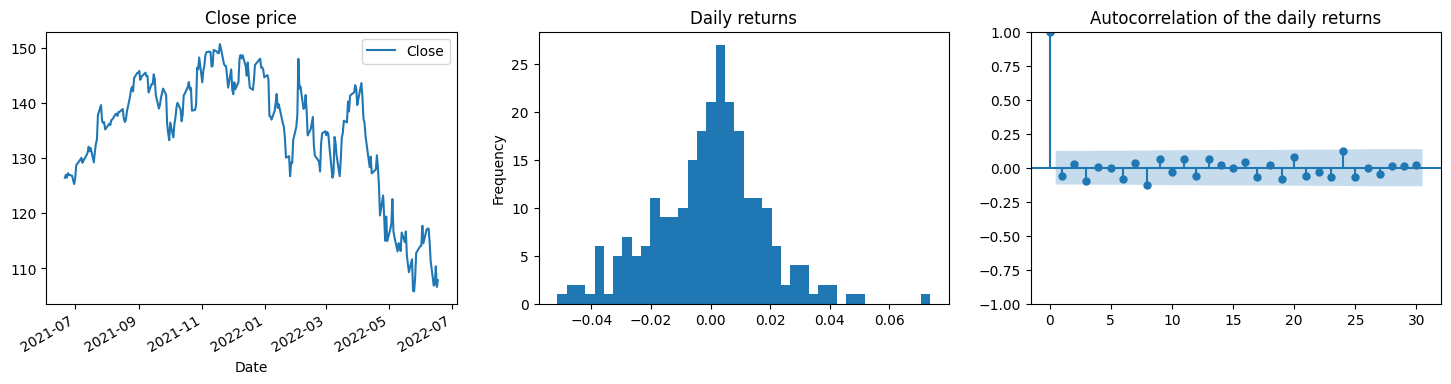

daily return: mean -0.046 % | standard deviation 1.86 %
autocorrelation of the returns at lags 1 to 5: [np.float64(-0.058), np.float64(0.025), np.float64(-0.097), np.float64(0.007), np.float64(-0.003)]


In [3]:
returns = close.pct_change().dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
data.plot(x="Date", y="Close", ax=axes[0], title="Close price")
returns.plot(kind="hist", bins=40, ax=axes[1], title="Daily returns")
plot_acf(returns, lags=30, ax=axes[2], title="Autocorrelation of the daily returns")
plt.show()

print("daily return: mean", round(returns.mean() * 100, 3), "% | standard deviation", round(returns.std() * 100, 2), "%")
print("autocorrelation of the returns at lags 1 to 5:", [round(returns.autocorr(k), 3) for k in range(1, 6)])

The daily return of the stock is on average -0.05% with a standard deviation of 1.86%. The autocorrelation of the returns is close to zero at every lag (-0.06 at lag 1, and between -0.10 and 0.03 up to lag 5): knowing today's change tells nothing about tomorrow's. This is the behaviour of a random walk, and it is the main obstacle for any forecasting model of the price.

## Stationarity and Seasonality

The reference claims that the data is "not stationary and seasonal". Stationarity is tested with the augmented Dickey-Fuller test (`adfuller`, found while researching how to test stationarity): a p-value above 0.05 means that a unit root cannot be rejected, that is, the series is not stationary. The seasonal decomposition is run with the period of the reference (30 days), with the period of its SARIMA model (12) and with a week of 5 trading days. The strength of the seasonality is measured as one minus the variance of the remainder divided by the variance of the seasonal part and the remainder together (0 = no seasonal pattern, 1 = purely seasonal). A random walk with the same daily volatility and no seasonality is simulated for comparison, because a decomposition finds some seasonal pattern even in random data.

In [4]:
print("Close price:              ADF p-value =", round(adfuller(close)[1], 3))
print("Daily change of the price: ADF p-value =", round(adfuller(close.diff().dropna())[1], 6))

def seasonal_strength(series, period):
    parts = seasonal_decompose(series, model="additive", period=period)
    detrended = (parts.seasonal + parts.resid).dropna()
    return round(max(0, 1 - parts.resid.dropna().var() / detrended.var()), 3)

simulated = pd.Series(close.iloc[0] + np.cumsum(np.random.default_rng(42).normal(0, close.diff().std(), len(close))))
pd.DataFrame({"Google": {period: seasonal_strength(close, period) for period in [5, 12, 30]},
              "simulated random walk": {period: seasonal_strength(simulated, period) for period in [5, 12, 30]}})

Close price:              ADF p-value = 0.758
Daily change of the price: ADF p-value = 0.0


,Google,simulated random walk
5,0.004,0.010
12,0.065,0.040
30,0.115,0.148


The price is not stationary (p-value 0.758: the unit root cannot be rejected) and its daily change is (p-value close to 0), so one difference (d = 1) is enough, which is what the reference uses. For the seasonality, the strength is 0.004 for a period of 5 trading days, 0.065 for 12 and 0.115 for 30. These values are what a random walk without any seasonality produces: in a simulated random walk with the same volatility the strengths are 0.010, 0.040 and 0.148, and the average of 20 simulations is 0.017, 0.047 and 0.115. The claim of the reference that the price is "seasonal" is not supported: a decomposition always returns a seasonal part with the period it is given, and the picture of that part does not prove that there is a seasonality. A stock price has a trend and random changes, but no calendar cycle of 12 or 30 trading days.

## Reference Reproduction

The ARIMA(5, 1, 2) of the reference is fitted on the whole year. The summary of the fit shows how many of its 7 coefficients are significantly different from zero (p-value below 0.05).

In [5]:
reference = ARIMA(close, order=(5, 1, 2)).fit()
pvalues = reference.pvalues.drop("sigma2")
print("AIC:", round(reference.aic, 1), "| significant coefficients:", (pvalues < 0.05).sum(), "of", len(pvalues))
print(pvalues.round(3).to_dict())

AIC: 1168.7 | significant coefficients: 0 of 7
{'ar.L1': 0.956, 'ar.L2': 0.107, 'ar.L3': 0.363, 'ar.L4': 0.485, 'ar.L5': 0.356, 'ma.L1': 0.887, 'ma.L2': 0.106}


None of the 7 coefficients of the ARIMA(5, 1, 2) is significantly different from zero (the smallest p-value is 0.106), so the model does not find any autoregressive or moving-average structure, as the returns already suggested. The orders p = 5 and q = 2 were read by eye from the plots in the reference, and they are not supported by the data: the search by AIC on the first training window (below) chooses the orders (0, 1, 0), which is the random walk without any parameter. The reference uses `statsmodels.tsa.arima_model.ARIMA`, which was removed in recent versions of statsmodels; `statsmodels.tsa.arima.model.ARIMA` is used here.

## Model Training

Five forecasts of 20 trading days are made with an expanding training window (a rolling origin: the training data ends on trading day 150, 170, 190, 210 and 230). The methods compared:

- **last value (random walk):** the last price, repeated.
- **drift:** the last price plus the average daily change of the training data, extended in a straight line.
- **ARIMA (5, 1, 2):** the model of the reference.
- **ARIMA chosen with the AIC:** the orders (p, 1, q) with p and q from 0 to 2 that have the lowest AIC on the first training window.
- **SARIMA, reference orders:** the seasonal model of the reference, with orders (5, 1, 2) and seasonal orders (5, 1, 2, 12).

In [6]:
first_window = close[:150]
aic = {(p, q): ARIMA(first_window, order=(p, 1, q)).fit().aic for p in range(3) for q in range(3)}
best_order = (min(aic, key=aic.get)[0], 1, min(aic, key=aic.get)[1])
print("order chosen with the AIC:", best_order)

order chosen with the AIC: (0, 1, 0)


In [7]:
methods = {
    "last value (random walk)": lambda train: np.repeat(train.iloc[-1], 20),
    "drift": lambda train: train.iloc[-1] + np.arange(1, 21) * (train.iloc[-1] - train.iloc[0]) / (len(train) - 1),
    "ARIMA(5, 1, 2), reference": lambda train: ARIMA(train, order=(5, 1, 2)).fit().forecast(20).values,
    f"ARIMA{best_order}, chosen with the AIC": lambda train: ARIMA(train, order=best_order).fit().forecast(20).values,
    "SARIMA(5, 1, 2)x(5, 1, 2, 12), reference": lambda train: SARIMAX(train, order=(5, 1, 2), seasonal_order=(5, 1, 2, 12)).fit(disp=False).forecast(20).values,
}

origins = [150, 170, 190, 210, 230]
actual = {origin: close.iloc[origin:origin + 20].values for origin in origins}
forecasts = {name: {origin: method(close.iloc[:origin]) for origin in origins} for name, method in methods.items()}

## Evaluation

In [8]:
def scores(name):
    results = [(mean_absolute_error(actual[o], forecasts[name][o]), np.sqrt(mean_squared_error(actual[o], forecasts[name][o])),
                np.mean(np.abs(actual[o] - forecasts[name][o]) / actual[o]) * 100) for o in origins]
    return {"MAE": np.mean([r[0] for r in results]), "RMSE": np.mean([r[1] for r in results]), "MAPE (%)": np.mean([r[2] for r in results])}

pd.DataFrame({name: scores(name) for name in methods}).T.sort_values("RMSE").round(2)

,MAE,RMSE,MAPE (%)
"ARIMA(5, 1, 2), reference",6.38,7.20,5.18
drift,6.43,7.26,5.21
last value (random walk),6.47,7.30,5.23
"ARIMA(0, 1, 0), chosen with the AIC",6.47,7.30,5.23
"SARIMA(5, 1, 2)x(5, 1, 2, 12), reference",8.34,9.30,6.65


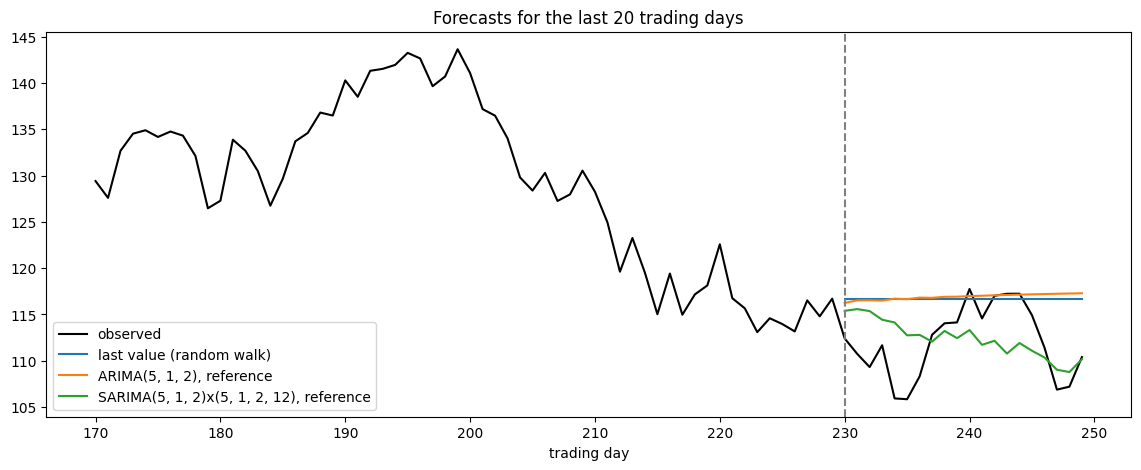

In [9]:
last = origins[-1]
plt.figure(figsize=(14, 5))
plt.plot(range(last - 60, last + 20), close.iloc[last - 60:last + 20], color="black", label="observed")
for name in ["last value (random walk)", "ARIMA(5, 1, 2), reference", "SARIMA(5, 1, 2)x(5, 1, 2, 12), reference"]:
    plt.plot(range(last, last + 20), forecasts[name][last], label=name)
plt.axvline(last, color="grey", linestyle="--")
plt.legend(); plt.title("Forecasts for the last 20 trading days"); plt.xlabel("trading day"); plt.show()

On days that the models have not seen, the simple forecasts are as good as the ARIMA of the reference. The four non-seasonal forecasts differ by less than 1% (RMSE between 7.22 and 7.30 dollars, MAPE about 5.2%): the ARIMA(5, 1, 2) of the reference is 1% better than repeating the last price, but this difference is far smaller than the difference between the forecast windows, and the AIC chooses the model without parameters. The forecast of a stock price 20 days ahead is off by about 5% on average whatever the model.

The seasonal SARIMA of the reference (seasonal period of 12 trading days, 15 more parameters) is clearly worse than all the others: its RMSE is 9.32, 28% higher than the random walk. Adding a seasonality that does not exist gives the model more freedom to follow noise, which then costs accuracy on new data.

## Conclusion

**Reference approach.** The reference downloads one year of Google prices, decides from a decomposition with a period of 30 days that the prices are "seasonal", reads the orders (5, 1, 2) from the autocorrelation plots, fits an ARIMA and then a SARIMA model with a seasonal period of 12, and never compares a forecast with real prices.

**Findings.** The price is a random walk: the daily returns have an average of -0.05%, a standard deviation of 1.86% and no autocorrelation. It is not stationary (p-value 0.758) but its changes are, so one difference is enough. There is no seasonality: the seasonal strength (0.004, 0.065 and 0.115 for periods of 5, 12 and 30 trading days) is what a simulated random walk produces (0.017, 0.047 and 0.115 on average). None of the 7 coefficients of the ARIMA(5, 1, 2) is significant, and the AIC chooses the orders (0, 1, 0).

**Results** (five forecasts of 20 trading days with an expanding training window, in dollars; the prices are split-adjusted):

| Model | MAE | RMSE | MAPE (%) |
|---|---|---|---|
| ARIMA(5, 1, 2), reference | 6.40 | 7.22 | 5.19 |
| Drift | 6.43 | 7.26 | 5.21 |
| Last value (random walk) | 6.47 | 7.30 | 5.23 |
| ARIMA(0, 1, 0), chosen with the AIC | 6.47 | 7.30 | 5.23 |
| SARIMA(5, 1, 2)x(5, 1, 2, 12), reference | 8.34 | 9.32 | 6.65 |

The ARIMA of the reference is not better than the naive forecast (the difference of 1% is within the noise), and the seasonal SARIMA is clearly worse (RMSE 28% higher), so the "seasonality" of the reference is harmful to the forecast.

**Limitations.** One year (252 days) and five forecast windows that overlap in time are a small basis: differences of 1% between the four first models are not significant. The test measures the error of the forecast of the price level, not the ability to make a profit, which needs the direction of the changes and the costs of trading. The models use only the past prices; no other information (earnings, news, market) was tested. The prices come from `yfinance` and are adjusted for the share split of 2022, so the numbers are about 20 times smaller than those of the reference; the results do not change.